<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 11.3</h1>

The aim of this exercise is to extend the neural network regression to a two-dimensional non-linear function,

$$
f(x,y)=\sin(x^2+y^2),
$$

defined in the region $x,y\in[-3/2,3/2]$. We will investigate how the neural network can learn the dependence of the output on two input variables and how the choice of the network architecture and training parameters affects the quality of the fit.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from mpl_toolkits.mplot3d import Axes3D

import pandas as pd

In [3]:
def f(x, y):
    return np.sin(x**2 + y**2)

In [5]:
def generate_data_2D(N_train, N_valid, sigma):

    #Data for x and y are saved in a matrix instead X_train_i = [x_i, y_i]
    
    X_train = np.random.uniform(-1.5, 1.5, (N_train, 2))
    X_valid = np.random.uniform(-1.5, 1.5, (N_valid, 2))

    y_target = f(X_valid[:, 0], X_valid[:, 1])

    y_train_true = f(X_train[:, 0], X_train[:, 1])

    y_train = np.random.normal(y_train_true, sigma)
    y_valid = np.random.normal(y_target, sigma)

    return X_train, y_train, X_valid, y_valid, y_target

In [28]:
def build_model_2D(neurons, activation="tanh", optimizer="adam"):

    model = Sequential()

    #Input layer
    model.add(Input(shape=(2,)))

    #Hidden layers
    for n_neurons in neurons:
        model.add(Dense(n_neurons, activation=activation))

    #Output layer
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss="mse", metrics=["mse"])

    return model

In [8]:
def run_experiment_2D(model, X_train, y_train, X_valid, y_valid, y_target, N_epochs, batch_size):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=100,
        restore_best_weights=True
    )

    history = model.fit( X_train, y_train, batch_size=batch_size, epochs=N_epochs, shuffle=True, validation_data=(X_valid, y_valid), callbacks=[early_stop], verbose=0)

    y_pred_train = model(X_train, training=False).numpy().flatten()
    y_pred_valid = model(X_valid, training=False).numpy().flatten()

    mse_train = np.mean((y_pred_train - y_train)**2)
    mse_valid = np.mean((y_pred_valid - y_valid)**2)
    mse_true = np.mean((y_pred_valid - y_target)**2)

    results = {
        "MSE_train": mse_train,
        "MSE_valid": mse_valid,
        "MSE_true": mse_true
    }

    return model, history, results

In [24]:
#First test
N_train_2D = 500
N_valid_2D = 100
sigma_2D = 0.2

N_epochs_2D = 2000
batch_size_2D = 32

n_neurons_2D = [10]
activation_2D = "tanh"
optimizer_2D = "adam"

In [25]:
X_train, y_train, X_valid, y_valid, y_target = generate_data_2D(N_train_2D, N_valid_2D, sigma_2D)

model_2D = build_model_2D(n_neurons=n_neurons_2D, activation=activation_2D, optimizer=optimizer_2D)

model_2D, history_2D, results_2D = run_experiment_2D(model_2D, X_train, y_train, X_valid, y_valid, y_target, N_epochs_2D, batch_size_2D)

print(f"MSE train : {results_2D['MSE_train']:.6e}")
print(f"MSE valid : {results_2D['MSE_valid']:.6e}")
print(f"MSE true  : {results_2D['MSE_true']:.6e}")

MSE train : 1.140440e-01
MSE valid : 8.725897e-02
MSE true  : 4.812894e-02


In [29]:
#Surface garph

x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_true = f(X_grid, Y_grid)

XY_grid = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

Z_pred = model_2D.predict(XY_grid, verbose=0).reshape(X_grid.shape)

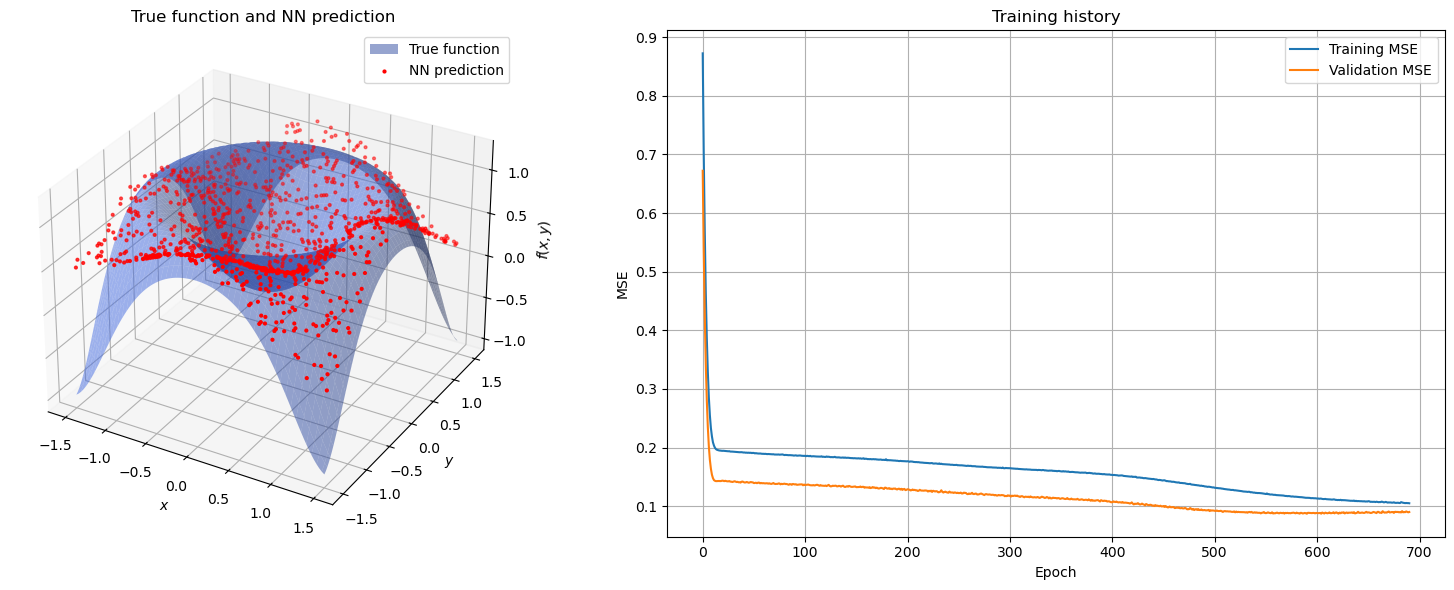

In [30]:
# Predicted values on the grid
Z_pred = model_2D.predict(XY_grid, verbose=0).reshape(X_grid.shape)

fig = plt.figure(figsize=(16, 6))

# Surface + prediction
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

# True function
ax1.plot_surface(
    X_grid,
    Y_grid,
    Z_true,
    color="royalblue",
    alpha=0.5,
    label="True function"
)

# NN prediction

N_points = 1000
rng = np.random.default_rng(0)

indices = rng.choice(X_grid.size, size=N_points, replace=False)

ax1.scatter(
    X_grid.ravel()[indices],
    Y_grid.ravel()[indices],
    Z_pred.ravel()[indices],
    color="red",
    s=4,
    label="NN prediction"
)

ax1.set_xlabel("$x$")
ax1.set_ylabel("$y$")
ax1.set_zlabel("$f(x,y)$")
ax1.set_title("True function and NN prediction")

ax1.legend()

# MSE history
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(
    history_2D.history["loss"],
    label="Training MSE"
)

ax2.plot(
    history_2D.history["val_loss"],
    label="Validation MSE"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE")
ax2.set_title("Training history")

ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

**Two-dimensional polynomial fit obtained with the first neural network configuration.** Comparison between the true function and the neural network prediction for the two-dimensional regression problem, together with the training and validation data points. The model is trained using $N_{\mathrm{train}}=500$ data points with noise level $\sigma=0.2$, for $N_{\mathrm{epochs}}=2000$ epochs, with $10$ neurons in the hidden layer, a hyperbolic tangent activation function, and the Adam optimizer. The neural network is able to reproduce the main features of the underlying function $f(x,y)=\sin(x^2+y^2)$ over the training region, although some discrepancies between the predicted and true surfaces are still visible. The resulting MSE values are $0.1140$ for the training set, $0.0873$ for the validation set, and $0.0481$ with respect to the true function. These results provide a first baseline for evaluating the improvements obtained by modifying the network architecture and training parameters.

### Testing for different architectures

To improve the performance of the neural network, we investigate the effect of the hidden-layer architecture on the quality of the fit. In particular, we test several configurations with an increasing number of neurons and hidden layers, namely $[10]$, $[20]$, $[50]$, $[10,10]$, $[20,20]$, $[30,30]$, and $[20,20,20]$. By comparing the corresponding MSE values, we aim to identify the architecture that provides the best compromise between model complexity and the ability to accurately reproduce the two-dimensional function.

In [31]:
#Testing for different architectures
architectures = [[10], [20], [50], [10, 10], [20, 20], [30, 30], [20, 20, 20]]

In [34]:
architecture_results = []
architecture_models = {}
architecture_histories = {}

for architecture in architectures:

    model_2D = build_model_2D(neurons=architecture, activation="tanh", optimizer="adam")

    model_2D, history_2D, results_2D = run_experiment_2D(model_2D, X_train, y_train, X_valid, y_valid, y_target, N_epochs_2D, batch_size_2D)

    architecture_results.append({"architecture": str(architecture), "MSE_train": results_2D["MSE_train"], "MSE_valid": results_2D["MSE_valid"], "MSE_true": results_2D["MSE_true"]})

    architecture_models[str(architecture)] = model_2D
    architecture_histories[str(architecture)] = history_2D

    print(
        f"Architecture: {architecture} | "
        f"MSE train: {results_2D['MSE_train']:.6e} | "
        f"MSE valid: {results_2D['MSE_valid']:.6e} | "
        f"MSE true: {results_2D['MSE_true']:.6e}"
    )

Architecture: [10] | MSE train: 1.398456e-01 | MSE valid: 1.064000e-01 | MSE true: 7.575315e-02
Architecture: [20] | MSE train: 8.142993e-02 | MSE valid: 8.109161e-02 | MSE true: 3.573219e-02
Architecture: [50] | MSE train: 1.832964e-01 | MSE valid: 1.320483e-01 | MSE true: 1.009117e-01
Architecture: [10, 10] | MSE train: 4.152227e-02 | MSE valid: 4.831534e-02 | MSE true: 7.435836e-03
Architecture: [20, 20] | MSE train: 3.961501e-02 | MSE valid: 4.523749e-02 | MSE true: 4.865084e-03
Architecture: [30, 30] | MSE train: 3.835204e-02 | MSE valid: 4.364181e-02 | MSE true: 5.936232e-03
Architecture: [20, 20, 20] | MSE train: 4.157376e-02 | MSE valid: 5.001928e-02 | MSE true: 9.332953e-03


In [40]:
architecture_data = pd.DataFrame(architecture_results)

architecture_data

,architecture,MSE_train,MSE_valid,MSE_true
0,[10],0.139846,0.106400,0.075753
1,[20],0.081430,0.081092,0.035732
2,[50],0.183296,0.132048,0.100912
3,"[10, 10]",0.041522,0.048315,0.007436
4,"[20, 20]",0.039615,0.045237,0.004865
5,"[30, 30]",0.038352,0.043642,0.005936
6,"[20, 20, 20]",0.041574,0.050019,0.009333


In [41]:
x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_true = f(X_grid, Y_grid)

XY_grid = np.column_stack((
    X_grid.ravel(),
    Y_grid.ravel()
))

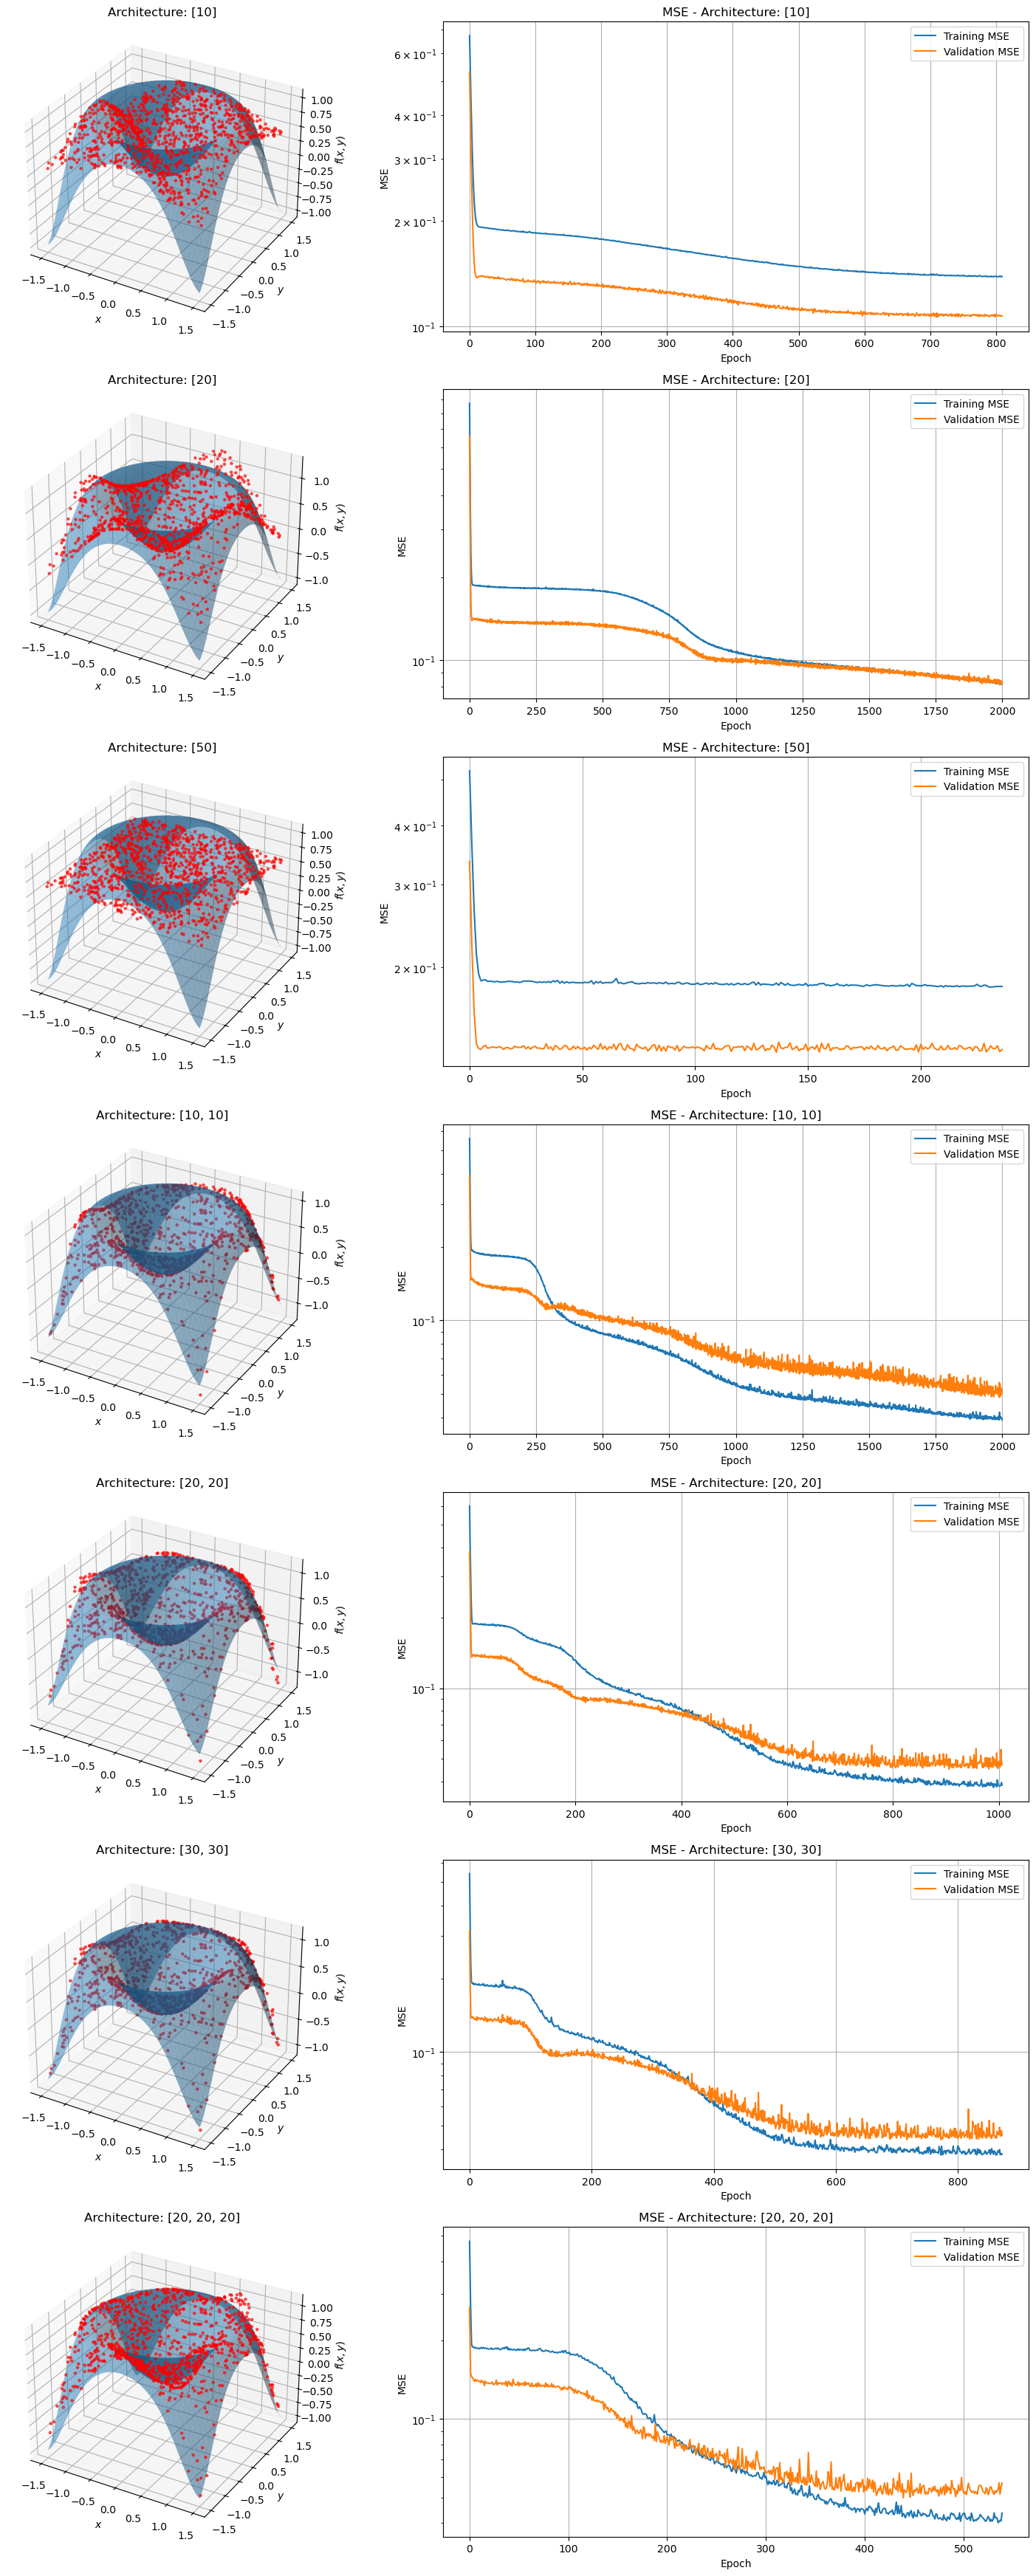

In [48]:
fig = plt.figure(figsize=(16, 5 * len(architectures)))

rng = np.random.default_rng(0)

N_points = 1000

indices = rng.choice(
    X_grid.size,
    size=min(N_points, X_grid.size),
    replace=False
)

for i, architecture in enumerate(architectures):

    architecture_key = str(architecture)

    model = architecture_models[architecture_key]
    history = architecture_histories[architecture_key]

    # --------------------------------------------------
    # Left: true surface + NN prediction
    # --------------------------------------------------

    ax1 = fig.add_subplot(
        len(architectures),
        2,
        2*i + 1,
        projection="3d"
    )

    Z_pred = model.predict(
        XY_grid,
        verbose=0
    ).reshape(X_grid.shape)

    ax1.plot_surface(
        X_grid,
        Y_grid,
        Z_true,
        alpha=0.5
    )

    ax1.scatter(
        X_grid.ravel()[indices],
        Y_grid.ravel()[indices],
        Z_pred.ravel()[indices],
        color="red",
        s=5,
        alpha=0.6,
        label="NN prediction"
    )

    ax1.set_xlabel("$x$")
    ax1.set_ylabel("$y$")
    ax1.set_zlabel("$f(x,y)$")

    ax1.set_title(
        f"Architecture: {architecture}"
    )

    # --------------------------------------------------
    # Right: MSE evolution
    # --------------------------------------------------

    ax2 = fig.add_subplot(
        len(architectures),
        2,
        2*i + 2
    )

    history_dict = history.history

    ax2.plot(
        history_dict["loss"],
        label="Training MSE"
    )

    ax2.plot(
        history_dict["val_loss"],
        label="Validation MSE"
    )

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE")

    ax2.set_title(
        f"MSE - Architecture: {architecture}"
    )

    ax2.set_yscale("log")

    ax2.grid(True)
    ax2.legend()

plt.tight_layout()
plt.show()

### Conclusions

The results show that increasing the complexity of the neural network can significantly improve its ability to approximate the two-dimensional function, but a larger network does not necessarily provide better predictions. In our tests, the architectures `[20,20]` and `[30,30]`  provided the best compromise between model complexity and generalization, achieving, the first, the lowest MSE with respect to the true function, while the second achieved the lowest MSE with respect to training and validation data.